In [ ]:
import numpy as np # para manipular arrays y realizar operaciones matematicas
import pandas as pd # para manipular dataframes y realizar operaciones de limpieza y analisis de datos
import matplotlib.pyplot as plt # para crear graficos y visualizaciones de datos
import seaborn as sns # para crear graficos y visualizaciones de datos mas avanzados y atractivos
import scipy as sp # general de scipy, aunque lo usaremos principalmente para estadistica
import scipy.stats as stats # para realizar pruebas de hipotesis y analisis estadistico
import pingouin as pg # para realizar pruebas de hipotesis y analisis estadistico de manera mas facil y rapida
import statsmodels.api as sm # para realizar pruebas de hipotesis y analisis estadistico de manera mas avanzada

# Distribuciones Discretas

## Principios de probabilidad

La probabilidad es un área de las matemáticas **muy** amplia. En resumidas cuentas, es el estudio de los fenómenos aleatorios.

En esta sección hablaremos principalmente sobre **distribuciones de probabilidad**, las cuales describen cómo se distribuye la frecuencia de ciertos eventos. A grandes rasgos, nos indican qué tan frecuente es que ocurra un determinado valor. Para comenzar a introducirlas, es necesario dividirlas en dos categorías según el tipo de variable que modelan.


Antes de entrar de lleno, existe una distinción fundamental según el tipo de variable que se quiere modelar:

- **Variable aleatoria discreta**: solo puede tomar valores contables (0, 1, 2, 3…). *Ejemplo: número de defectos en una pieza.*
- **Variable aleatoria continua**: puede tomar cualquier valor en un rango. *Ejemplo: temperatura de un reactor.*

Esta distinción cambia cómo se define la probabilidad y qué función se usa para describirla.

### Variable Aleatoria

Una **variable aleatoria** es una función que asigna un valor numérico a cada posible resultado de un experimento aleatorio. En términos simples, es una forma de convertir los resultados de un proceso incierto en números con los que podemos operar matemáticamente.

> **Ejemplo:** Si lanzamos una moneda dos veces, los resultados posibles son {CC, CS, SC, SS}. Si definimos $X$ = "número de caras obtenidas", entonces $X$ puede tomar los valores 0, 1 o 2. Eso es una variable aleatoria: transformó un resultado cualitativo en un número.

En ingeniería, casi todo lo que medimos es una variable aleatoria: la temperatura de un reactor, el número de piezas defectuosas en un lote, el tiempo hasta que falla un equipo. La incertidumbre en el proceso es lo que le da el carácter "aleatorio".

Sobre las variables aleatorias se definen funciones que describen cómo se distribuye su probabilidad:

| Función | Nombre | Aplica a | Qué responde |
|---|---|---|---|
| **PMF** — *Probability Mass Function* | Función de masa de probabilidad | Variables **discretas** | ¿Cuál es la probabilidad de que $X$ tome exactamente el valor $x$? → $P(X = x)$ |
| **PDF** — *Probability Density Function* | Función de densidad de probabilidad | Variables **continuas** | ¿Qué tan densa es la probabilidad alrededor de $x$? La probabilidad se obtiene integrando en un intervalo |
| **CDF** — *Cumulative Distribution Function* | Función de distribución acumulada | **Ambas** | ¿Cuál es la probabilidad de que $X$ sea menor o igual a $x$? → $P(X \leq x)$ |

> ⚠️ Para una variable continua, $P(X = x) = 0$ siempre. Esto se debe a que hay infinitos valores posibles, por lo que la probabilidad de caer en un punto exacto es cero. Por eso se trabaja con la PDF y se calculan probabilidades sobre intervalos.

## Distribuciones Discretas

Para modelar variables aleatorias discretas se tienen las siguientes funciones:

> **Probability Mass Function (PMF) — Función de Masa de Probabilidad**
>
> Para una variable aleatoria discreta $X$, la **PMF** nos dice cuál es la probabilidad de que $X$ tome >exactamente el valor $x$:
>
>$$f(x) = P(X = x)$$
>
>Dos propiedades que siempre se cumplen:
>1. $f(x) \geq 0$ para todo $x$
>2. $\sum_{\text{todos los } x} f(x) = 1$

> **Cumulative Distribution Function (CDF) — Función de Distribución Acumulada**
>La **CDF** nos dice la probabilidad de que $X$ sea *menor o igual* a $x$:
>
>$$F(x) = P(X \leq x) = \sum_{x_i \leq x} f(x_i)$$
>

Para una variable aleatoria discreta, se tiene que la media y la varianza se computan de la siguiente forma:

>**Media**
>$$\mu = E[X] = \sum_x x \cdot f(x)$$

>**Varianza**
>$$\sigma^2 = V[X] = \sum_x (x - \mu)^2 \cdot f(x) = E[X^2] - \mu^2$$

Notemos que, a diferencia de las medias y varianzas muestrales, en este caso trabajamos sobre una función, no datos.

Para modelarlas usamos `scipy.stats`, este paquete contiene la gran mayoria de distribuciones útiles. Una vez definida la distribución, se puede llamar a:

| Método | Qué hace |
|--------|----------|
| `.pmf(k)` | PMF: $P(X = k)$ — *solo discreta* |
| `.pdf(x)` | PDF: densidad en $x$ — *solo continua* |
| `.cdf(x)` | CDF: $P(X \leq x)$ |
| `.sf(x)` | Survival Function: $P(X > x) = 1 - F(x)$ |
| `.ppf(q)` | Percentil / cuantil: valor $x$ tal que $P(X \leq x) = q$ |
| `.rvs(size=n)` | Genera $n$ números aleatorios de esa distribución |
| `.mean()` | Media teórica $\mu$ |
| `.std()` | Desviación estándar teórica $\sigma$ |
| `.var()` | Varianza teórica $\sigma^2$ |


En las siguientes secciones trabajaremos sobre distribuciones de probabilidad. Estas son funciones que asignan de diferentes maneras probabilidad a variables aleatorias. Estas son útilies debido a que nos permiten modelar diferentes fénomenos de la realdiad. 

### Distribución Bernoulli — `stats.bernoulli`

La más sencilla de todas. Modela un experimento con **solo dos resultados**: éxito (1) o fracaso (0).

**Parámetro:** $p$ = probabilidad de éxito

$$P(X = x) = p^x (1-p)^{1-x}, \quad x \in \{0, 1\}$$

- $E[X] = p$
- $V[X] = p(1-p)$

> **Ejemplo:** ¿una pieza es defectuosa? ¿un producto pasa control de calidad?

In [38]:
p = 0.3  # probabilidad de éxito

dist_bernoulli = stats.bernoulli(p)

# PMF
print(f"P(X=0) = {dist_bernoulli.pmf(0):.3f}")   # P(fracaso)
print(f"P(X=1) = {dist_bernoulli.pmf(1):.3f}")   # P(éxito)

# Media y varianza
print(f"Media:    {dist_bernoulli.mean():.3f}")
print(f"Varianza: {dist_bernoulli.var():.3f}")

P(X=0) = 0.700
P(X=1) = 0.300
Media:    0.300
Varianza: 0.210


### Distribución Binomial — `stats.binom`

Extensión de Bernoulli: cuenta el número de éxitos en $n$ ensayos **independientes**, cada uno con probabilidad de éxito $p$.

**Parámetros:** $n$ (número de ensayos), $p$ (probabilidad de éxito)

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, \ldots, n$$

- $E[X] = np$
- $V[X] = np(1-p)$

> **Ejemplo:** En un lote de 20 piezas, ¿cuántas serán defectuosas si $p_{defecto} = 0.1$?

P(X=2) = 0.2852
P(X<=3) = 0.8670
P(X>3) = 0.1330
Media: 2.00
Varianza: 1.80


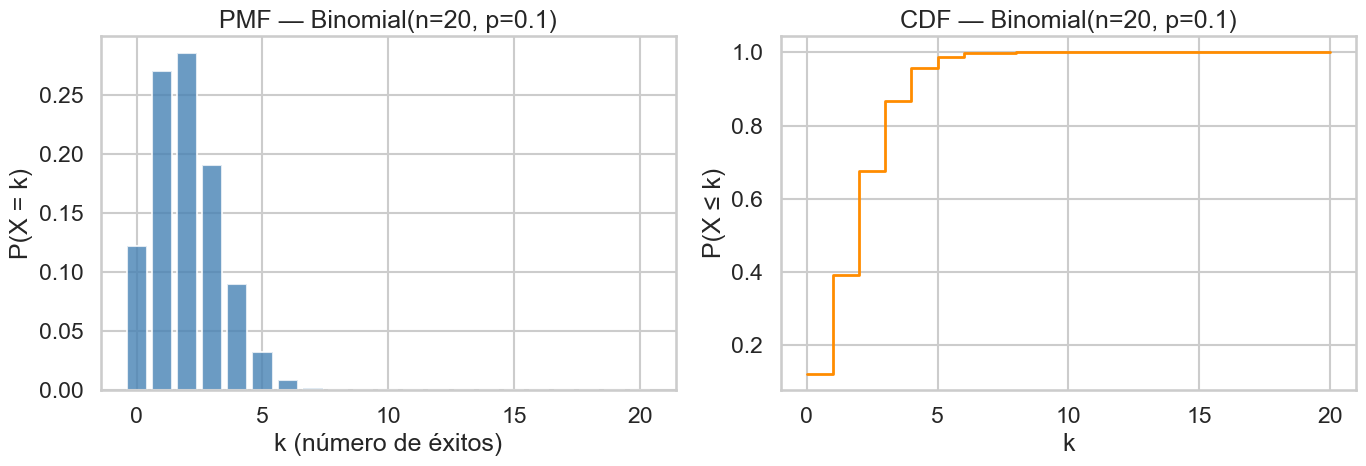

In [39]:
n, p = 20, 0.1

dist_binom = stats.binom(n, p)

# P(X = 2) — exactamente 2 defectuosas
print(f"P(X=2) = {dist_binom.pmf(2):.4f}")

# P(X <= 3) — 3 o menos defectuosas
print(f"P(X<=3) = {dist_binom.cdf(3):.4f}")

# P(X > 3) — más de 3 defectuosas (usando survival function)
print(f"P(X>3) = {dist_binom.sf(3):.4f}")

# Media y varianza
print(f"Media: {dist_binom.mean():.2f}")
print(f"Varianza: {dist_binom.var():.2f}")

# ---- Gráfico PMF y CDF -----
k_vals = np.arange(0, n+1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(k_vals, dist_binom.pmf(k_vals), color='steelblue', alpha=0.8)
axes[0].set_title(f'PMF — Binomial(n={n}, p={p})')
axes[0].set_xlabel('k (número de éxitos)')
axes[0].set_ylabel('P(X = k)')

axes[1].step(k_vals, dist_binom.cdf(k_vals), where='post', color='darkorange', linewidth=2)
axes[1].set_title(f'CDF — Binomial(n={n}, p={p})')
axes[1].set_xlabel('k')
axes[1].set_ylabel('P(X ≤ k)')

plt.tight_layout()
plt.show()

### Distribución Poisson — `stats.poisson`

Modela el **número de eventos** que ocurren en un intervalo de tiempo o espacio fijo, cuando los eventos ocurren a una tasa constante e independientemente entre sí.

**Parámetro:** $\lambda$ (tasa promedio de eventos por intervalo)

$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \ldots$$

- $E[X] = \lambda$
- $V[X] = \lambda$  <- media = varianza, una propiedad única de Poisson

> **Ejemplo:** Número de fallas de un equipo por semana, número de llamadas a un call center por hora.

P(X=0) = 0.0302
P(X<=2) = 0.3208
P(X>=5) = 0.2746
Media: 3.50
Varianza: 3.50


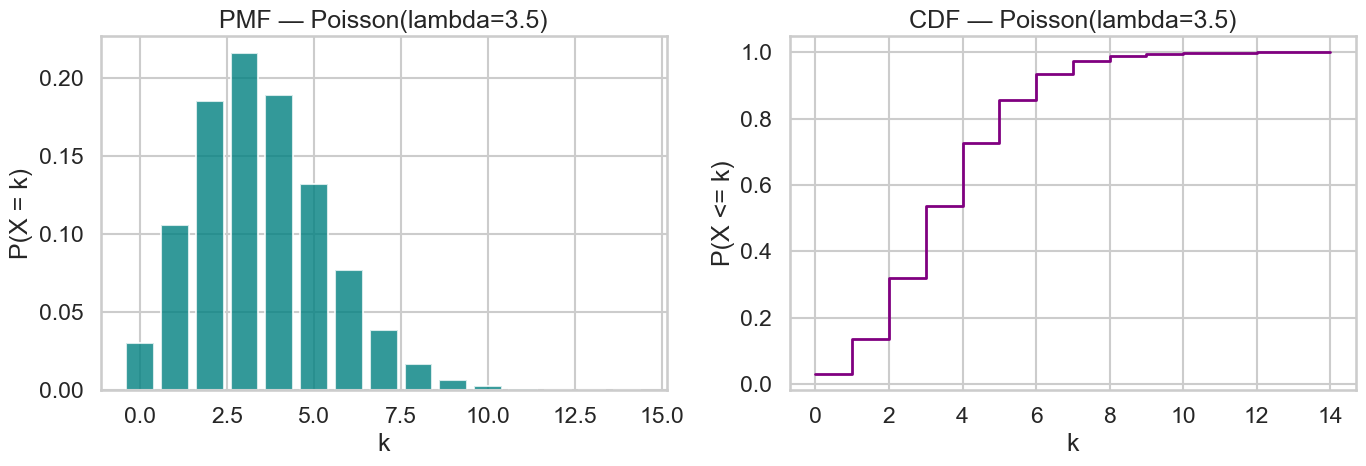

In [40]:
lam = 3.5  # promedio: 3.5 fallas por semana

dist_poisson = stats.poisson(lam)

# P(X = 0) - sin fallas esta semana
print(f"P(X=0) = {dist_poisson.pmf(0):.4f}")

# P(X <= 2)
print(f"P(X<=2) = {dist_poisson.cdf(2):.4f}")

# P(X >= 5) - 5 o más fallas
print(f"P(X>=5) = {dist_poisson.sf(4):.4f}")   # sf(4) = P(X>4) = P(X>=5)

print(f"Media: {dist_poisson.mean():.2f}")
print(f"Varianza: {dist_poisson.var():.2f}")

# --- Gráfico ----
k_vals = np.arange(0, 15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(k_vals, dist_poisson.pmf(k_vals), color='teal', alpha=0.8)
axes[0].set_title(f'PMF — Poisson(lambda={lam})')
axes[0].set_xlabel('k'); axes[0].set_ylabel('P(X = k)')

axes[1].step(k_vals, dist_poisson.cdf(k_vals), where='post', color='purple', linewidth=2)
axes[1].set_title(f'CDF — Poisson(lambda={lam})')
axes[1].set_xlabel('k'); axes[1].set_ylabel('P(X <= k)')

plt.tight_layout()
plt.show()

### Distribución Geométrica — `stats.geom`

Cuenta el **número de ensayos necesarios hasta obtener el primer éxito**.

**Parámetro:** $p$ (probabilidad de éxito en cada ensayo)

$$P(X = k) = (1-p)^{k-1} p, \quad k = 1, 2, 3, \ldots$$

- $E[X] = \frac{1}{p}$
- $V[X] = \frac{1-p}{p^2}$

> **Ejemplo:** ¿Cuántos intentos se necesitan hasta que una máquina produzca una pieza sin defectos?

> ⚠️ `scipy.stats.geom` usa la convención $k = 1, 2, 3, \ldots$ (contando desde el primer intento).

P(X=1) = 0.2500
P(X<=4) = 0.6836
Media (intentos esperados): 4.00
Varianza: 12.00


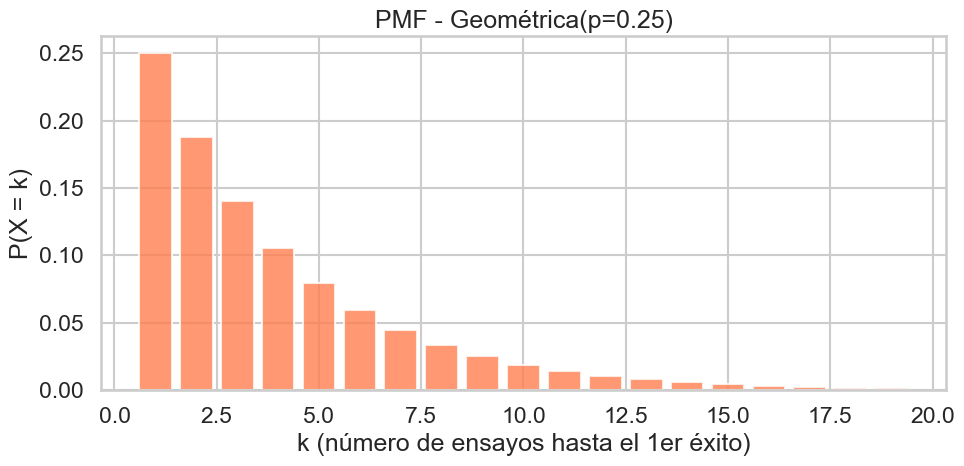

In [41]:
p = 0.25  # probabilidad de éxito

dist_geom = stats.geom(p)

# P(X = 1) - éxito en el primer intento
print(f"P(X=1) = {dist_geom.pmf(1):.4f}")

# P(X <= 4) - éxito dentro de los primeros 4 intentos
print(f"P(X<=4) = {dist_geom.cdf(4):.4f}")

print(f"Media (intentos esperados): {dist_geom.mean():.2f}")
print(f"Varianza: {dist_geom.var():.2f}")

# ---- Gráfico -----
k_vals = np.arange(1, 20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(k_vals, dist_geom.pmf(k_vals), color='coral', alpha=0.8)
ax.set_title(f'PMF - Geométrica(p={p})')
ax.set_xlabel('k (número de ensayos hasta el 1er éxito)')
ax.set_ylabel('P(X = k)')
plt.tight_layout()
plt.show()

### Distribución Hipergeométrica — `stats.hypergeom`

Similar a la Binomial, pero **sin reemplazo**. Se usa cuando se muestrea de una población finita.

**Parámetros:**
- $M$: tamaño total de la población
- $n$: número de elementos "de interés" en la población (éxitos posibles)
- $N$: tamaño de la muestra extraída

$$P(X = k) = \frac{\binom{n}{k}\binom{M-n}{N-k}}{\binom{M}{N}}$$

- $E[X] = N \cdot \frac{n}{M}$
- $V[X] = N \cdot \frac{n}{M} \cdot \frac{M-n}{M} \cdot \frac{M-N}{M-1}$

> **Ejemplo:** En un lote de 50 piezas (10 defectuosas), se inspeccionan 8 al azar. ¿Cuántas defectuosas se esperan encontrar?

P(X=2) = 0.3217
P(X=0) = 0.1432
Media: 1.60
Varianza: 1.10


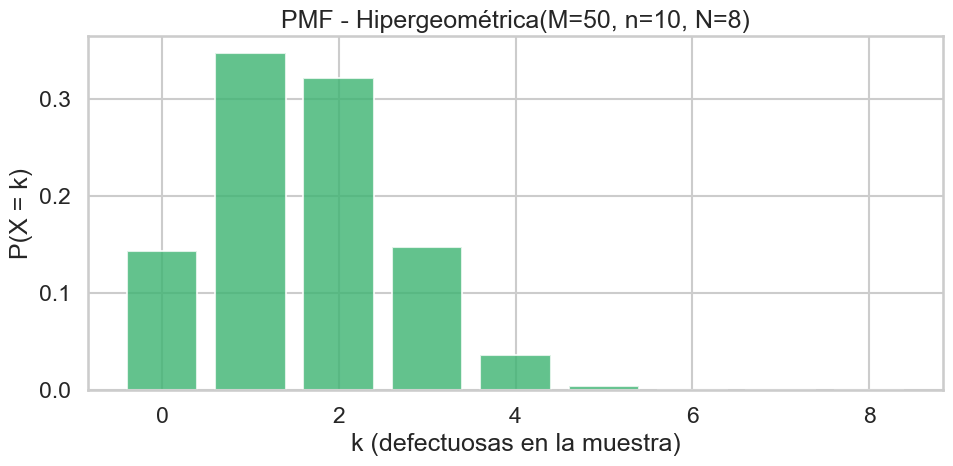

In [42]:
M = 50 # población total
n = 10 # defectuosas en el lote
N = 8 # muestra inspeccionada

dist_hyper = stats.hypergeom(M=M, n=n, N=N)

# P(X = 2) - exactamente 2 defectuosas en la muestra
print(f"P(X=2) = {dist_hyper.pmf(2):.4f}")

# P(X = 0) - ninguna defectuosa en la muestra
print(f"P(X=0) = {dist_hyper.pmf(0):.4f}")

print(f"Media: {dist_hyper.mean():.2f}")
print(f"Varianza: {dist_hyper.var():.2f}")

# ----- Gráfico ----
k_vals = np.arange(0, min(n, N)+1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(k_vals, dist_hyper.pmf(k_vals), color='mediumseagreen', alpha=0.8)
ax.set_title(f'PMF - Hipergeométrica(M={M}, n={n}, N={N})')
ax.set_xlabel('k (defectuosas en la muestra)')
ax.set_ylabel('P(X = k)')
plt.tight_layout()
plt.show()

### Resumen: Distribuciones Discretas

| Distribución | Parámetros | Media | Varianza | Uso típico |
|---|---|---|---|---|
| Bernoulli | $p$ | $p$ | $p(1-p)$ | Experimento binario único |
| Binomial | $n, p$ | $np$ | $np(1-p)$ | $k$ éxitos en $n$ ensayos independientes |
| Poisson | $\lambda$ | $\lambda$ | $\lambda$ | Conteo de eventos raros en tiempo/espacio |
| Geométrica | $p$ | $1/p$ | $(1-p)/p^2$ | Ensayos hasta el primer éxito |
| Hipergeométrica | $M, n, N$ | $Nn/M$ | — | Muestreo sin reemplazo |